# 01 — Elliptic++ EDA (D1, primary financial anchor)

Week-1 goals (implementation-plan.md §7 step 3, §4.3 D1): verify the plan's stated counts — **203,769 tx nodes, 234,355 edges, 49 time steps, 183 features, 4,545 illicit / 42,019 licit** — and look at label prevalence over time.

*Read-only after merge. Data: `data/raw/elliptic_pp/` (never committed).*

In [1]:
import polars as pl

RESULTS = []

def check(name, expected, actual):
    """Soft verification: record PASS/FAIL, never crash mid-notebook."""
    ok = expected == actual
    RESULTS.append((name, expected, actual, ok))
    print(f"{'PASS' if ok else 'FAIL'}  {name}: expected={expected!r} actual={actual!r}")
    return ok

def summary():
    print("\n=== VERIFICATION SUMMARY ===")
    for name, exp, act, ok in RESULTS:
        print(f"{'PASS' if ok else 'FAIL'}  {name}: expected={exp!r} actual={act!r}")
    n_fail = sum(1 for r in RESULTS if not r[3])
    print(f"{len(RESULTS) - n_fail}/{len(RESULTS)} checks passed")


In [2]:
DATA = "../data/raw/elliptic_pp"
features = pl.read_csv(f"{DATA}/txs_features.csv", infer_schema_length=10000)
classes = pl.read_csv(f"{DATA}/txs_classes.csv", infer_schema_length=10000)
edges = pl.read_csv(f"{DATA}/txs_edgelist.csv", infer_schema_length=10000)
print("features:", features.shape, "classes:", classes.shape, "edges:", edges.shape)
print("first 8 feature columns:", features.columns[:8])

features: (203769, 184) classes: (203769, 2) edges: (234355, 2)
first 8 feature columns: ['txId', 'Time step', 'Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5', 'Local_feature_6']


In [3]:
# Node / edge / time-step counts vs. the plan
check("tx nodes", 203_769, features.height)
check("directed edges", 234_355, edges.height)
ts_col = [c for c in features.columns if "time" in c.lower().replace("_", "")][0]
print("time-step column:", ts_col)
check("time steps", 49, features[ts_col].n_unique())
# Feature count: total columns minus the txId column = per-node feature vector
id_col = features.columns[0]
n_features = features.width - 1
check("features per tx (plan: 183, incl. the time step)", 183, n_features)

PASS  tx nodes: expected=203769 actual=203769
PASS  directed edges: expected=234355 actual=234355
time-step column: Time step
PASS  time steps: expected=49 actual=49
PASS  features per tx (plan: 183, incl. the time step): expected=183 actual=183


True

In [4]:
# Label distribution (unknown-label policy: §4.3 D1)
label_col = classes.columns[-1]
counts = classes[label_col].value_counts().sort("count", descending=True)
print(counts)
as_str = classes[label_col].cast(pl.Utf8)
n_illicit = (as_str == "1").sum()
n_licit = (as_str == "2").sum()
n_unknown = classes.height - n_illicit - n_licit
check("illicit (class 1)", 4_545, n_illicit)
check("licit (class 2)", 42_019, n_licit)
print(f"unknown: {n_unknown} ({n_unknown / classes.height:.1%})")
print(f"illicit prevalence among ALL txs: {n_illicit / classes.height:.2%}")
print(f"illicit prevalence among LABELED txs: {n_illicit / (n_illicit + n_licit):.2%}")

shape: (3, 2)
┌───────┬────────┐
│ class ┆ count  │
│ ---   ┆ ---    │
│ i64   ┆ u32    │
╞═══════╪════════╡
│ 3     ┆ 157205 │
│ 2     ┆ 42019  │
│ 1     ┆ 4545   │
└───────┴────────┘
PASS  illicit (class 1): expected=4545 actual=4545
PASS  licit (class 2): expected=42019 actual=42019
unknown: 157205 (77.1%)
illicit prevalence among ALL txs: 2.23%
illicit prevalence among LABELED txs: 9.76%


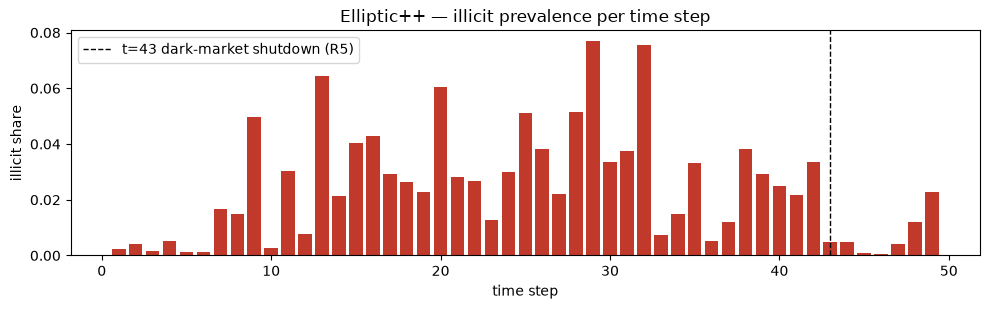

In [5]:
# Illicit share per time step — context for the step-43 distribution shift (R5)
import matplotlib.pyplot as plt
df = features.select([pl.col(id_col), pl.col(ts_col)]).join(
    classes.rename({classes.columns[0]: id_col}), on=id_col, how="left"
)
per_ts = (
    df.with_columns(pl.col(label_col).cast(pl.Utf8))
    .group_by(ts_col)
    .agg([
        (pl.col(label_col) == "1").sum().alias("illicit"),
        (pl.col(label_col) == "2").sum().alias("licit"),
        pl.len().alias("total"),
    ])
    .sort(ts_col)
)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(per_ts[ts_col], per_ts["illicit"] / per_ts["total"], color="#c0392b")
ax.axvline(43, color="k", ls="--", lw=1, label="t=43 dark-market shutdown (R5)")
ax.set_xlabel("time step"); ax.set_ylabel("illicit share"); ax.legend()
ax.set_title("Elliptic++ — illicit prevalence per time step")
plt.tight_layout(); plt.show()

In [6]:
summary()


=== VERIFICATION SUMMARY ===
PASS  tx nodes: expected=203769 actual=203769
PASS  directed edges: expected=234355 actual=234355
PASS  time steps: expected=49 actual=49
PASS  features per tx (plan: 183, incl. the time step): expected=183 actual=183
PASS  illicit (class 1): expected=4545 actual=4545
PASS  licit (class 2): expected=42019 actual=42019
6/6 checks passed


**Conclusions.** Counts verified against §4.3 D1 (any FAIL above is a discrepancy to record in PROGRESS.md). The ~2% illicit prevalence among all transactions confirms the extreme-imbalance regime (§4.4); the temporal split (train ≤34 / test ≥35, strict-inductive) and the t=43 shift are Week-2 splitter concerns.